In [1]:
import numpy as np
import matplotlib.pyplot as plt

from doppler import calculate_doppler_beta

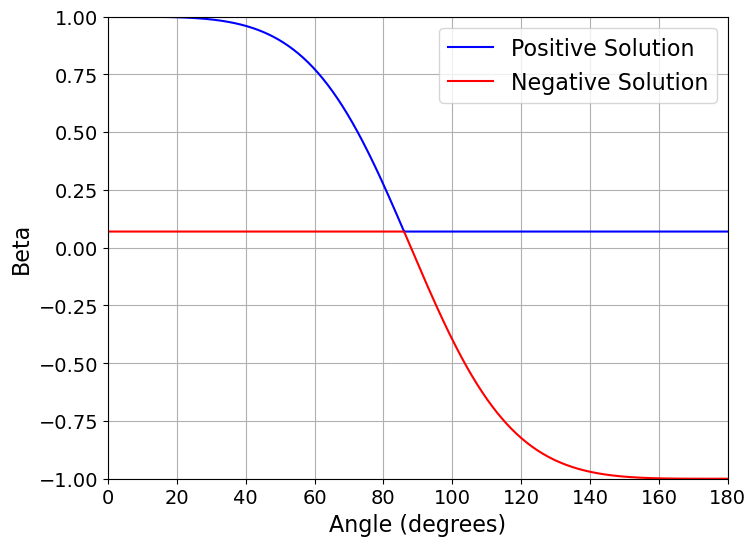

In [ ]:
beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(6.792, energy_offset=0.0, angle_offset=0.0, fixed_beta=0.07)

plt.figure(figsize=(8, 6))
plt.plot(np.rad2deg(theta_vals), beta_vals1, label='Positive Solution', color='blue')
plt.plot(np.rad2deg(theta_vals), beta_vals2, label='Negative Solution', color='red')

plt.xlim(0, 180)
plt.ylim(-1, 1)

plt.xlabel('Angle (degrees)', fontsize=16)
plt.ylabel('Beta', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid()

plt.legend(fontsize=16)

plt.show()

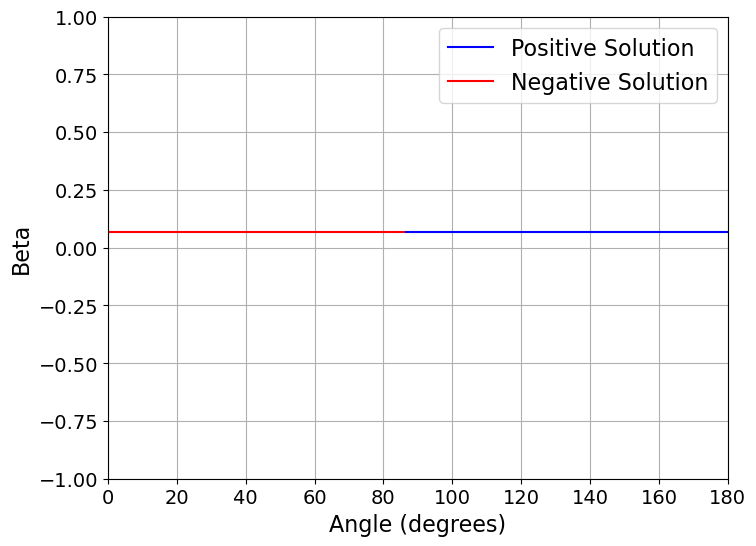

In [3]:
beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(6.792, energy_offset=0.0, angle_offset=0.0, fixed_beta=0.07)

# mask values with theta > 90 degrees
mask = np.rad2deg(theta_vals) > 86
theta_vals1 = theta_vals[mask]
beta_vals1 = beta_vals1[mask]
beta_vals2 = beta_vals2[~mask]
theta_vals2 = theta_vals[~mask]


plt.figure(figsize=(8, 6))
plt.plot(np.rad2deg(theta_vals1), beta_vals1, label='Positive Solution', color='blue')
plt.plot(np.rad2deg(theta_vals2), beta_vals2, label='Negative Solution', color='red')

plt.xlim(0, 180)
plt.ylim(-1, 1)

plt.xlabel('Angle (degrees)', fontsize=16)
plt.ylabel('Beta', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid()

plt.legend(fontsize=16)

plt.show()

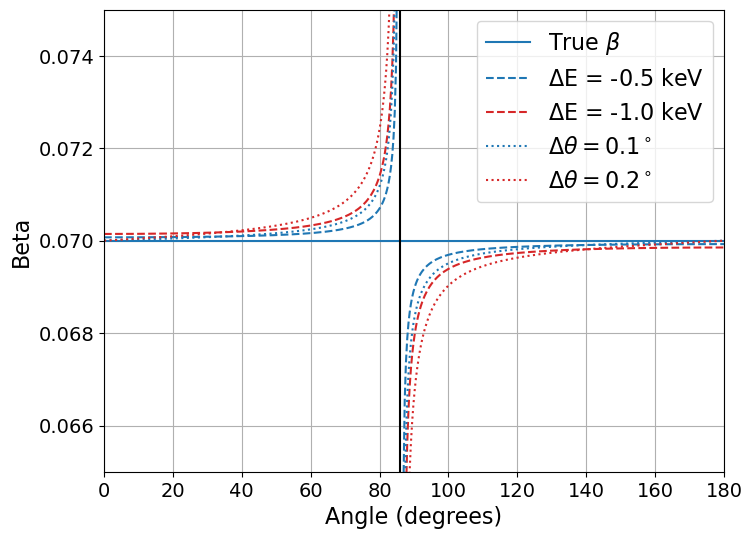

In [35]:
def select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86):
    mask = np.rad2deg(theta_vals) > theta_cut
    theta_vals1 = theta_vals[mask]
    beta_vals1 = beta_vals1[mask]
    beta_vals2 = beta_vals2[~mask]
    theta_vals2 = theta_vals[~mask]
    return theta_vals1, beta_vals1, theta_vals2, beta_vals2

plt.figure(figsize=(8, 6))

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(6.792, energy_offset=0.0, angle_offset=0.0, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2)

plt.plot(np.rad2deg(x1), y1, label=r'True $\beta$', color='tab:blue')
plt.plot(np.rad2deg(x2), y2, color='tab:blue')

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(6.792, energy_offset=-0.0005, angle_offset=0.0, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta$E = -0.5 keV', color='tab:blue', linestyle='--')
plt.plot(np.rad2deg(x2), y2, color='tab:blue', linestyle='--')

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(6.792, energy_offset=-0.0010, angle_offset=0.0, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta$E = -1.0 keV', color='tab:red', linestyle='--')
plt.plot(np.rad2deg(x2), y2, color='tab:red', linestyle='--')

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(6.792, energy_offset=0.0, angle_offset=0.1, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta\theta = 0.1^\circ$', color='tab:blue', linestyle=':')
plt.plot(np.rad2deg(x2), y2, color='tab:blue', linestyle=':')

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(6.792, energy_offset=0.0, angle_offset=0.2, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta\theta = 0.2^\circ$', color='tab:red', linestyle=':')
plt.plot(np.rad2deg(x2), y2, color='tab:red', linestyle=':')

plt.axvline(86, color='black')

plt.xlim(0, 180)
plt.ylim(-1, 1)

plt.xlabel('Angle (degrees)', fontsize=16)
plt.ylabel('Beta', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.ylim(0.07 - 0.005, 0.07 + 0.005)

plt.grid()

plt.legend(fontsize=16)

plt.show()